# 🥔 Potato Disease Classification Using CNN
**Dataset:** PlantVillage | **Framework:** TensorFlow/Keras | **Classes:** Early Blight, Late Blight, Healthy

## 1. Import Libraries

In [15]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Configuration

In [16]:
BATCH_SIZE  = 32
IMAGE_SIZE  = 256
CHANNELS    = 3
EPOCHS      = 50

# UPDATE THIS PATH to your PlantVillage folder
DATASET_PATH = r"C:\Users\HP\OneDrive\Desktop\python\Deep Learning\NLP\Plantvillage\PlantVillage"

CLASS_NAMES = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

## 3. Load Dataset

In [17]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    shuffle=True,
    seed=42,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
print("Classes found:", class_names)
print("Total batches:", len(dataset))

Found 2152 files belonging to 3 classes.
Classes found: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Total batches: 68


## 4. Visualise Sample Images

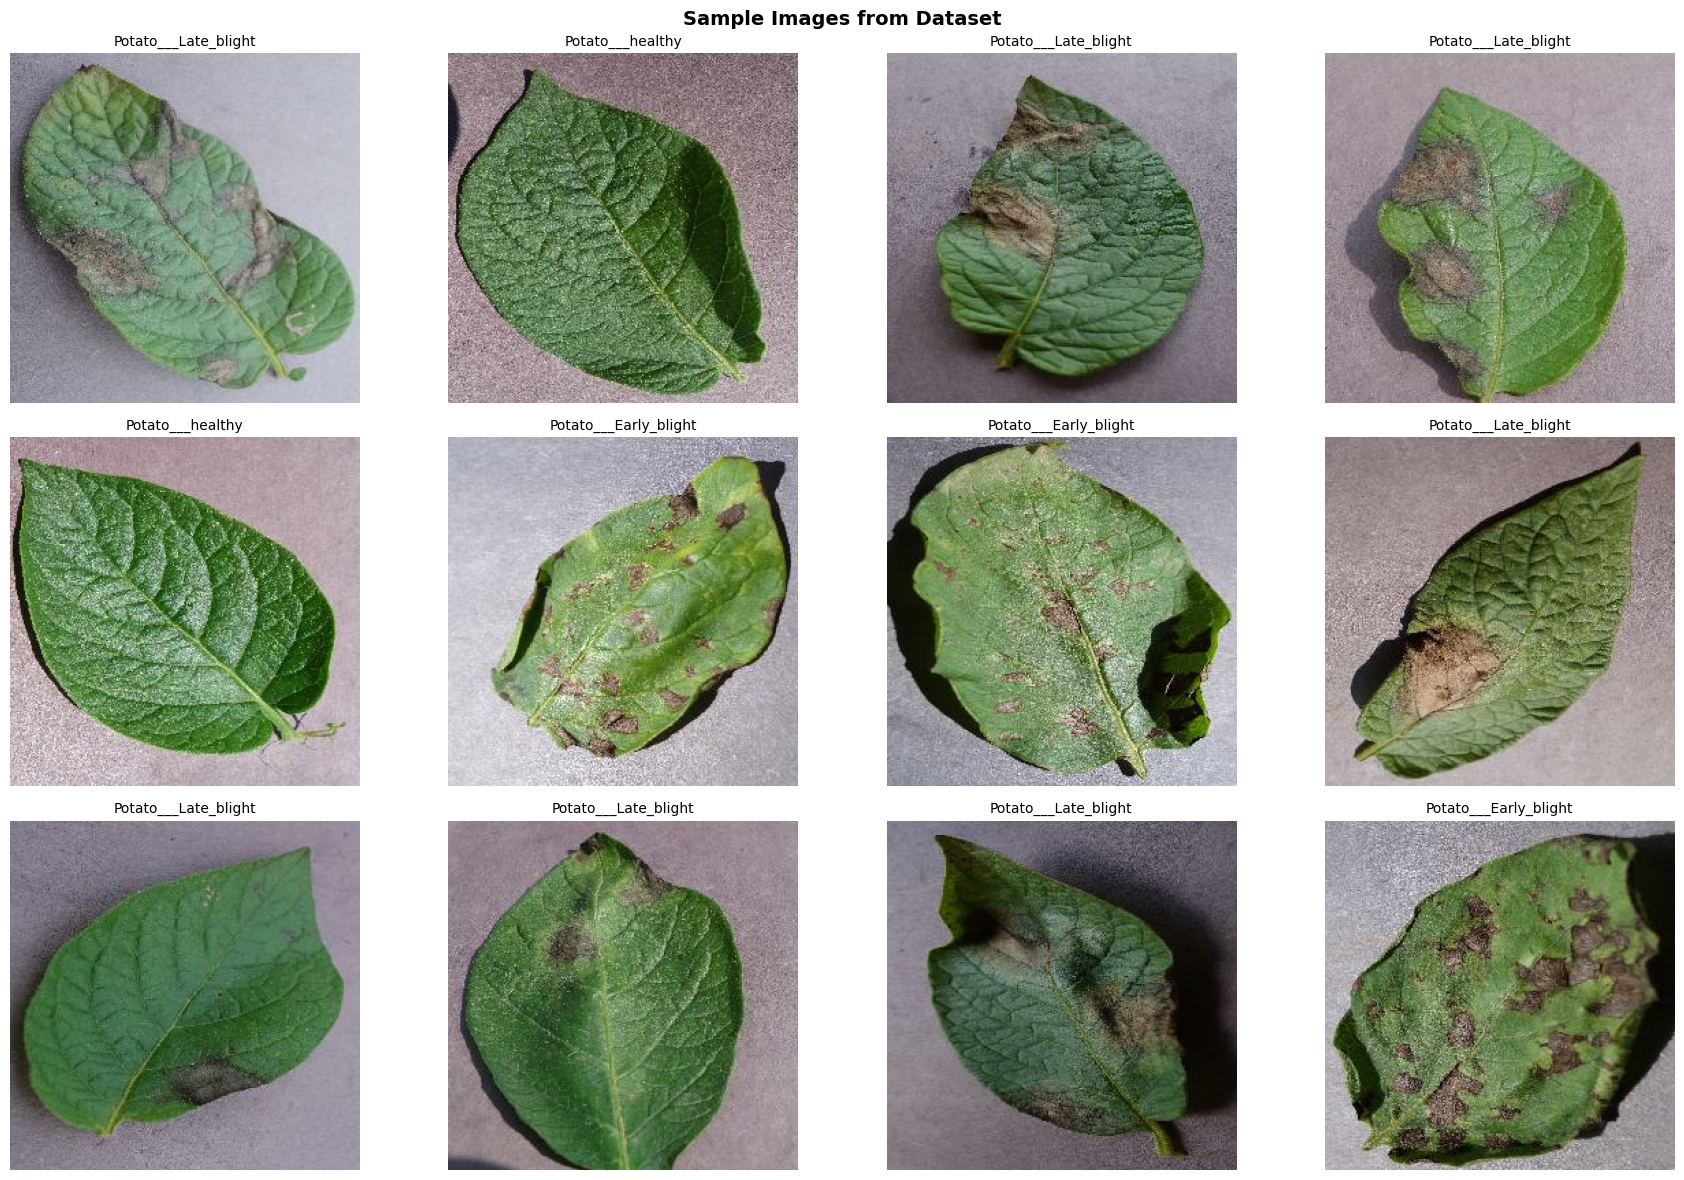

In [18]:
plt.figure(figsize=(18, 12))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]], fontsize=10)
        plt.axis("off")
plt.suptitle("Sample Images from Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Train / Validation / Test Split (80 / 10 / 10)

In [19]:
def split_dataset(ds, train_split=0.8, val_split=0.1, test_split=0.1,
                  shuffle=True, shuffle_size=10000):
    assert (train_split + val_split + test_split) == 1

    ds_size   = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size   = int(val_split   * ds_size)

    train_ds = ds.take(train_size)
    val_ds   = ds.skip(train_size).take(val_size)
    test_ds  = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = split_dataset(dataset)

print(f"Train batches      : {len(train_ds)}")
print(f"Validation batches : {len(val_ds)}")
print(f"Test batches       : {len(test_ds)}")

Train batches      : 54
Validation batches : 6
Test batches       : 8


## 6. Preprocessing — Resize, Rescale, and Augmentation

In [20]:
AUTOTUNE = tf.data.AUTOTUNE

# --- Resize + Normalise ---
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
], name="resize_rescale")

# --- Augmentation (applied only during training) ---
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
], name="data_augmentation")

# --- Apply augmentation to training set only ---
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

# --- Performance pipeline ---
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Preprocessing pipeline ready ")

Preprocessing pipeline ready 


## 7. Build CNN Model

In [21]:
n_classes = 3

model = tf.keras.Sequential([
    resize_and_rescale,

    # Block 1
    layers.Conv2D(32,(3,3),activation='relu',
                  input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    # Block 3
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    # Block 4
    layers.Conv2D(256,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Block 5
    layers.Conv2D(256,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    layers.Dense(n_classes, activation='softmax')
], name="potato_cnn")

model.build((BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
model.summary()

Model: "potato_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resize_rescale (Sequential)     │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 60, 60, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 30, 30, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (32, 30, 30, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 28, 28, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 14, 14, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (32, 14, 14, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (32, 12, 12, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (32, 6, 6, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 9216)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 128)              │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 3)                │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,158,659 (8.23 MB)

 Trainable params: 2,158,659 (8.23 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Compile the Model

In [22]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)
print("Model compiled ")

Model compiled 


## 9. Train the Model (50 Epochs)

In [23]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.4676 - loss: 0.9555 - val_accuracy: 0.4479 - val_loss: 0.9058
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6875 - loss: 0.7074 - val_accuracy: 0.8333 - val_loss: 0.5497
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8090 - loss: 0.4719 - val_accuracy: 0.7865 - val_loss: 0.5115
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 284s 5s/step - accuracy: 0.8420 - loss: 0.4049 - val_accuracy: 0.7604 - val_loss: 0.7147
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8611 - loss: 0.3625 - val_accuracy: 0.8698 - val_loss: 0.3486
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.9387 - loss: 0.1814 - val_accuracy: 0.9479 - val_loss: 0.1536
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9520 - loss: 0.1281 - val_accuracy: 0.9427 - val_loss: 0.1294
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9560 - loss: 0.1255 - val_accuracy: 0.9115 - val_los

## 10. Plot Training Curves

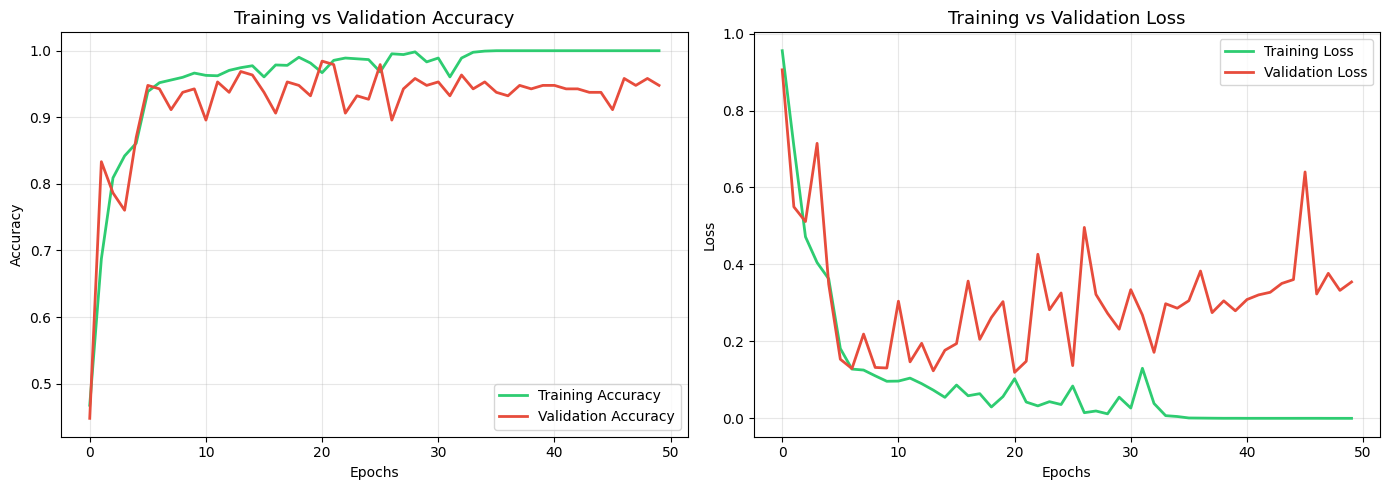

Saved: training_curves.png


In [24]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc,     label='Training Accuracy',   color='#2ecc71', linewidth=2)
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy', color='#e74c3c', linewidth=2)
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy', fontsize=13)
plt.xlabel('Epochs'); plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)

# Loss
plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss,     label='Training Loss',   color='#2ecc71', linewidth=2)
plt.plot(range(EPOCHS), val_loss, label='Validation Loss', color='#e74c3c', linewidth=2)
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss', fontsize=13)
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

## 11. Evaluate on Test Set

In [25]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n{'='*40}")
print(f"  Test Accuracy : {round(test_acc * 100, 2)}%")
print(f"  Test Loss     : {round(test_loss, 4)}")
print(f"{'='*40}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 335ms/step - accuracy: 0.9453 - loss: 0.2558

  Test Accuracy : 94.53%
  Test Loss     : 0.2558


## 12. Prediction Function

In [26]:
def predict(model, image_tensor, class_names):
    """
    Predict disease from a single image tensor (H, W, C).
    Returns: (predicted_class: str, confidence: float)
    """
    img_with_batch = tf.expand_dims(image_tensor, 0)      # → (1, H, W, C)
    predictions    = model.predict(img_with_batch, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence      = round(100 * float(np.max(predictions[0])), 2)
    return predicted_class, confidence

print("predict() function ready ")

predict() function ready 


## 13. Visualise Test Predictions

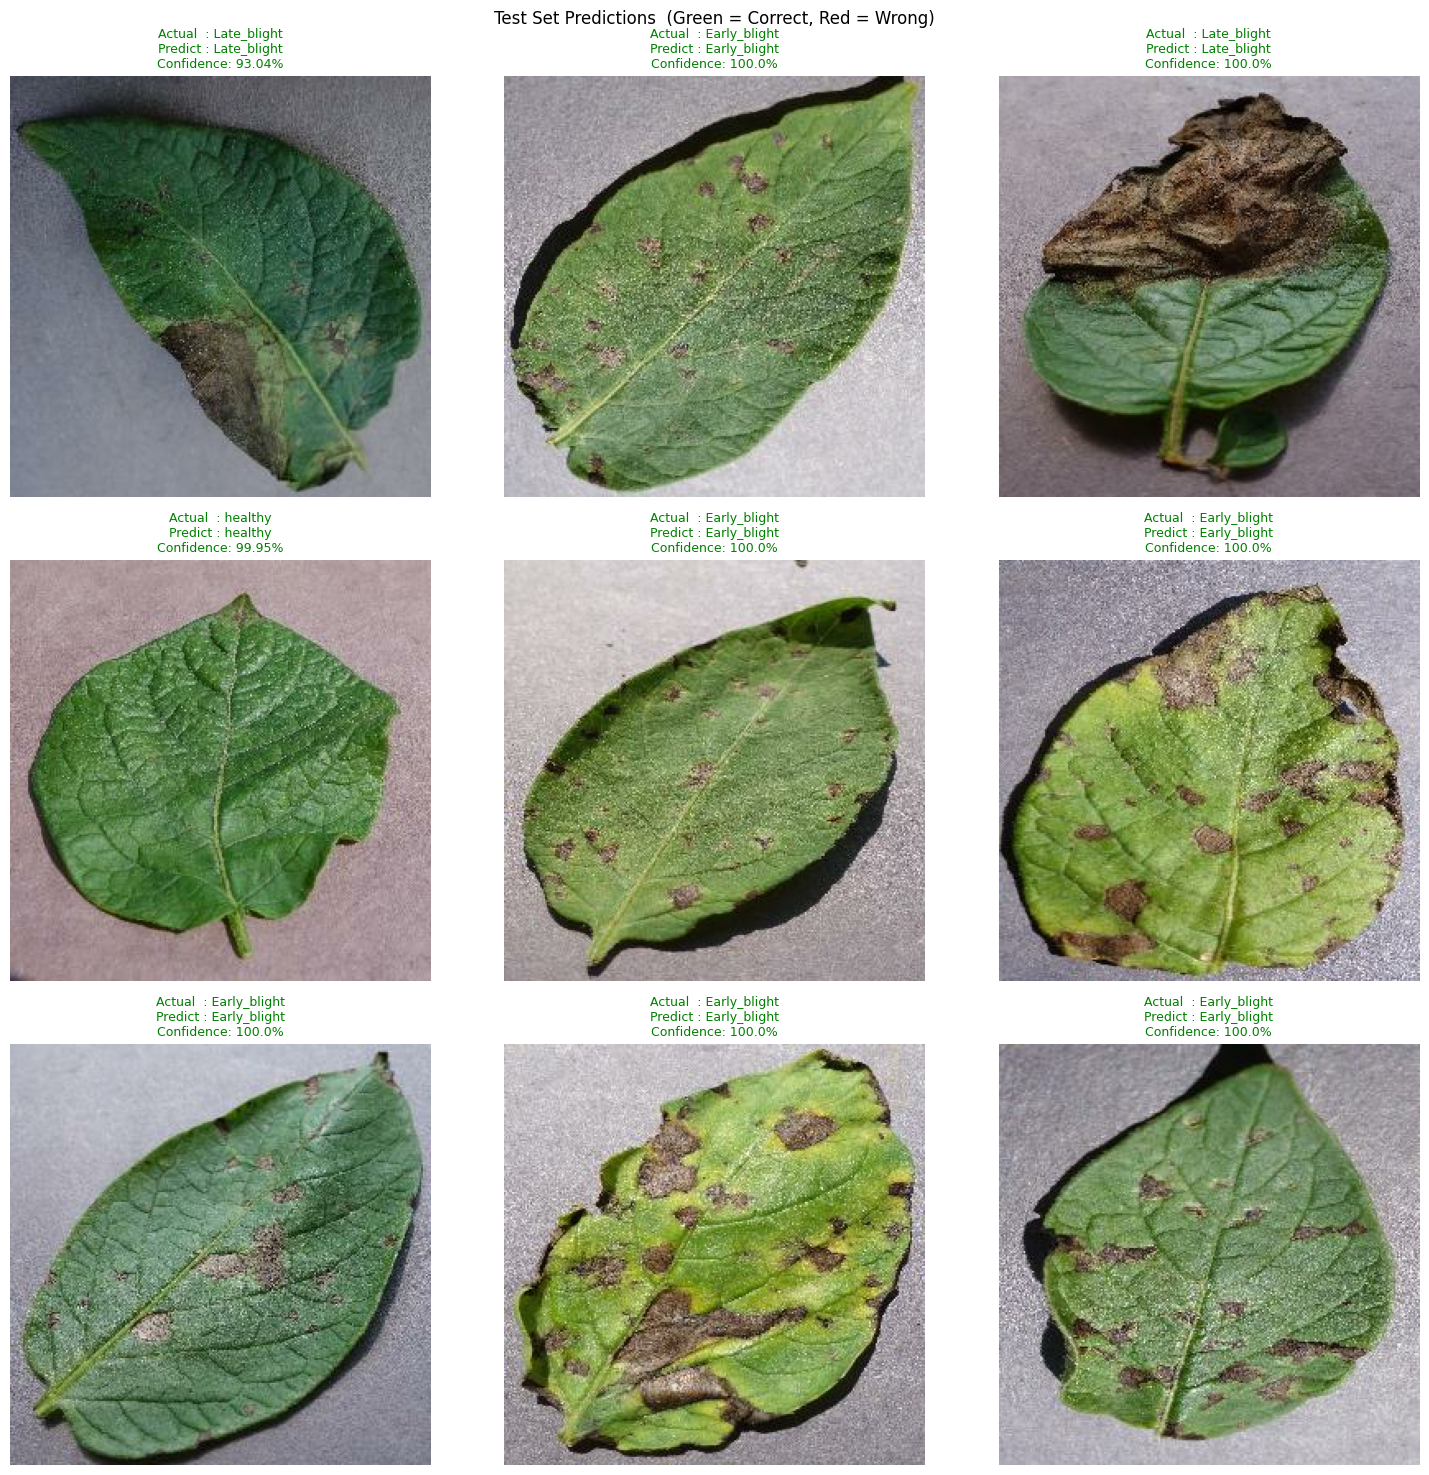

Saved: sample_predictions.png


In [27]:
plt.figure(figsize=(15, 15))

for image_batch, label_batch in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))

        pred_class, conf = predict(model, image_batch[i], class_names)
        actual_class     = class_names[label_batch[i]]

        color = 'green' if pred_class == actual_class else 'red'
        plt.title(
            f"Actual  : {actual_class.split('___')[-1]}\n"
            f"Predict : {pred_class.split('___')[-1]}\n"
            f"Confidence: {conf}%",
            fontsize=9, color=color
        )
        plt.axis("off")

plt.suptitle("Test Set Predictions  (Green = Correct, Red = Wrong)", fontsize=12)
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sample_predictions.png")

## 14. Save the Trained Model

In [28]:
import os

# Save with .keras extension (required by Keras 3)
os.makedirs("models", exist_ok=True)

save_path = os.path.join("models", "1.keras")
model.save(save_path)
print(f"Model saved to: {save_path} ")

# To load later:
# loaded_model = tf.keras.models.load_model("models/1.keras")

Model saved to: models\1.keras 


---
## ✅ Project Complete!

| Output | File |
|--------|------|
| Training curves | `training_curves.png` |
| Sample predictions | `sample_predictions.png` |
| Saved model | `models/1/` |